In [1]:
import pandas as pd
import joblib
import sys
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

sys.path.append('../src')
from text_features import url_tokenizer

df = pd.read_csv('../data/malicious_phish.csv')
df['label'] = df['type'].apply(lambda x: 0 if x == 'benign' else 1)

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
print(f"Test set : {df_test.shape[0]} lignes")

Test set : 130239 lignes


In [2]:
import re

IP_PATTERN = re.compile(
    r'^(?:(?:25[0-5]|2[0-4]\d|[01]?\d\d?)\.){3}(?:25[0-5]|2[0-4]\d|[01]?\d\d?)$'
)

SHORTENER_PATTERN = re.compile(
    r'bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
    r'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
    r'short\.to|budurl\.com|ping\.fm|post\.ly|just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
    r'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|lnkd\.in|'
    r'db\.tt|qr\.ae|adf\.ly|bitly\.com|cur\.lv|ity\.im|q\.gs|po\.st|bc\.vc|twitthis\.com|'
    r'u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|prettylinkpro\.com|scrnch\.me|'
    r'filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|link\.zip\.net'
)


def is_ip_address(domain):
    host = domain.split(':')[0]
    return int(bool(IP_PATTERN.match(host)))


def has_numeric_label(domain):
    host = domain.split(':')[0]
    return int(any(part.isdigit() for part in host.split('.')))


def has_shortener(url):
    return int(bool(SHORTENER_PATTERN.search(url.lower())))


def extract_features_v3(url):
    try:
        if not url.startswith('http'):
            url = 'http://' + url
        parsed = urlparse(url)
        domain = parsed.netloc
        path = parsed.path
    except Exception:
        domain = ''
        path = ''

    suspicious_tlds = ['.tk', '.ml', '.ga', '.cf', '.gq', '.free.fr', '.xyz', '.top']
    suspicious_words = ['login', 'secure', 'update', 'verify', 'account',
                        'banking', 'paypal', 'amazon', 'apple', 'microsoft']

    return {
        'length': len(url),
        'num_dots': url.count('.'),
        'num_hyphens': url.count('-'),
        'num_slashes': url.count('/'),
        'num_digits': sum(c.isdigit() for c in url),
        'num_at': url.count('@'),
        'num_percent': url.count('%'),
        'num_question': url.count('?'),
        'num_equal': url.count('='),
        'num_underscore': url.count('_'),
        'has_https': int(url.startswith('https')),
        'has_ip': is_ip_address(domain),
        'has_numeric_label': has_numeric_label(domain),
        'domain_length': len(domain),
        'path_length': len(path),
        'has_suspicious_tld': int(any(url.endswith(tld) or tld + '/' in url for tld in suspicious_tlds)),
        'has_suspicious_word': int(any(word in domain.lower() for word in suspicious_words)),
        'num_subdomains': len(domain.split('.')) - 2 if len(domain.split('.')) > 2 else 0,
        'has_at_in_url': int('@' in url),
        'has_shortener': has_shortener(url),
    }


print("Fonctions définies")

Fonctions définies


In [3]:
rf_model_v3 = joblib.load('../models/rf_phishing_model_v3.pkl')
tfidf_pipeline = joblib.load('../models/tfidf_logreg_model.pkl')

y_test = df_test['label'].values

X_test_struct = pd.DataFrame(df_test['url'].apply(extract_features_v3).tolist())
proba_v3 = rf_model_v3.predict_proba(X_test_struct)[:, 1]

proba_tfidf = tfidf_pipeline.predict_proba(df_test['url'])[:, 1]

print("Prédictions calculées sur", len(y_test), "lignes")

Prédictions calculées sur 130239 lignes


In [4]:
pred_v3 = (proba_v3 >= 0.5).astype(int)
pred_tfidf = (proba_tfidf >= 0.5).astype(int)

ensemble_proba = (proba_v3 + proba_tfidf) / 2
pred_ensemble = (ensemble_proba >= 0.5).astype(int)

print("=== v3 seul (structurel) ===")
print(f"Accuracy : {accuracy_score(y_test, pred_v3)*100:.2f}%")

print("\n=== TF-IDF seul (textuel) ===")
print(f"Accuracy : {accuracy_score(y_test, pred_tfidf)*100:.2f}%")

print("\n=== Ensemble (moyenne des deux) ===")
print(f"Accuracy : {accuracy_score(y_test, pred_ensemble)*100:.2f}%")
print(classification_report(y_test, pred_ensemble, target_names=['Benign', 'Malicious']))

=== v3 seul (structurel) ===
Accuracy : 92.01%

=== TF-IDF seul (textuel) ===
Accuracy : 94.16%

=== Ensemble (moyenne des deux) ===
Accuracy : 96.91%
              precision    recall  f1-score   support

      Benign       0.97      0.98      0.98     85778
   Malicious       0.96      0.94      0.95     44461

    accuracy                           0.97    130239
   macro avg       0.97      0.96      0.97    130239
weighted avg       0.97      0.97      0.97    130239



FileNotFoundError: [Errno 2] No such file or directory: '../img/roc_curves.png'

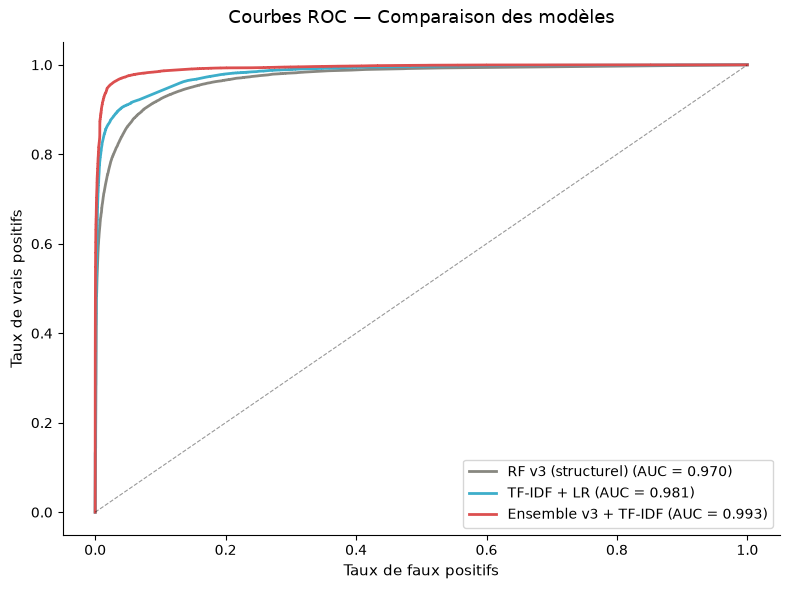

In [5]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

modeles = [
    ('RF v3 (structurel)',  proba_v3,       '#888780'),
    ('TF-IDF + LR',         proba_tfidf,    '#3DAECA'),
    ('Ensemble v3 + TF-IDF', ensemble_proba, '#DC4F4F'),
]

for nom, proba, couleur in modeles:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{nom} (AUC = {roc_auc:.3f})', color=couleur, linewidth=2)

ax.plot([0,1],[0,1], 'k--', linewidth=0.8, alpha=0.4)
ax.set_xlabel('Taux de faux positifs', fontsize=11)
ax.set_ylabel('Taux de vrais positifs', fontsize=11)
ax.set_title('Courbes ROC — Comparaison des modèles', fontsize=13, pad=14)
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../img/roc_curves.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()